In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**3-5*x**2+2*x

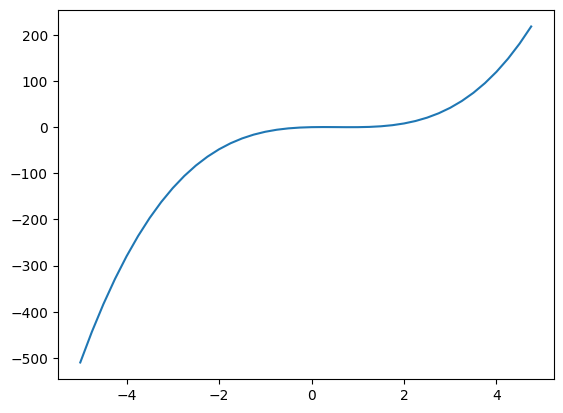

In [3]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [4]:
h=0.0001
x=1
d=(f(x+h)-f(x))/h
d

1.0004000299934646

In [5]:
a = 22.0
b = -20.0
c = 10.0
d = a*b-c
e= 15.0
f = d*e
L=f
print(d)

-450.0


In [6]:
h=0.001
# chain rule df/da=df/dd*dd/da
# confirm using the following code
a = 22.0+h
b = -20.0
c = 10.0
d = a*b-c
e= 15.0
f = d*e
L1=f
print((L1-L)/h)


-300.0000000001819


In [17]:
# value object
class Value():
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.grad=0.0
        self._prev=set(_children)# children was empty tupple initially
        self._op=_op
        self.label=label

    def __repr__(self):# gives a readable output nothing else
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out= Value(self.data + other.data, (self, other),'+')
        return out
    def __mul__(self,other):
        out= Value(self.data*other.data,(self,other),'*')
        return out
    def tanh(self):# nothing but a squashing function
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out =Value(t, (self,),'tanh')
        return out



In [ ]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L1= L.tanh(); L1.label ='out'

In [ ]:
# import sys
# !{sys.executable} -m pip install graphviz

In [19]:
# dot graph
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [32]:
# basic example of manual backpropagation
# example taken directly from lectures
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


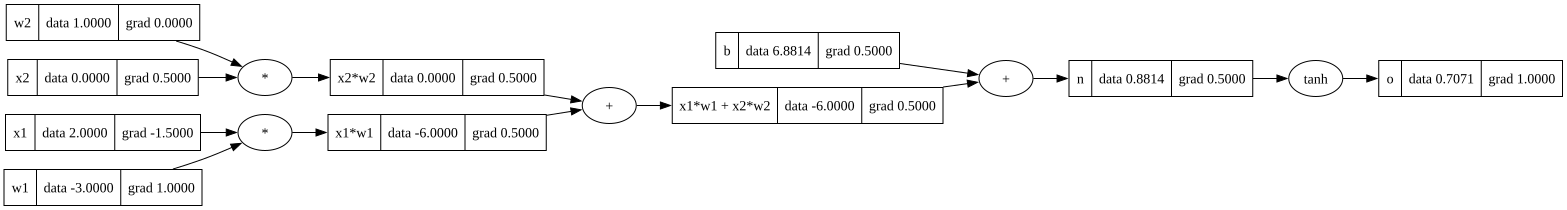

In [36]:
draw_dot(o)

In [37]:
# always look at local derivative multiplied with other
o.grad =1.0
n.grad= 1-o.data**2 # dtanh(x)/dx= 1-tanh(x)**2
# addition is just distributer of gradient
b.grad=n.grad
x1w1x2w2.grad=n.grad
# again addition 
x1w1.grad=x1w1x2w2.grad
x2w2.grad=x1w1x2w2.grad
# multiplication = prev.grad * other term
# in addition this other term is 1 therefore only prev.grad
x1.grad = x1w1.grad*w1.data
w1.grad = x1w1.grad*x1.data
x2.grad = x2w2.grad*w2.data
w2.grad = x2w2.grad*x2.data
# in formal terms gradient = upstream gradient * local derivative